# Data Engineer — Task 1: Data Quality Assessment
### NovaCred Credit Applications Dataset

---

This section systematically audits `raw_credit_applications.json` against all four data quality dimensions relevant for detecting bias patterns.

| # | Dimension | Definition | Issue Found | 
|---|-----------|-------------|------------|
| 1 | **Completeness** | Is all required data present and populated? | Missing fields (gender, income, DOB, email, SSN, timestamp) |
| 2 | **Consistency** | Does data in one place match relevant data stored elsewhere? |Inconsistent gender coding, 3 date formats, string income |
| 3 | **Validity** | Does data conform to defined formats, types, and business rules? |Negative credit history, DTI > 1, negative savings balance |
| 4 | **Accuracy** | Does data correctly reflect real-world facts?| Duplicate IDs with conflicting data |

Each subsection: **detects → quantifies → remediates**.


## Table of Contents

1. [Data Loading](#1-data-loading)
   - 1.1 [Load Raw JSON](#11-load-raw-json)
   - 1.2 [Flatten to DataFrame](#12-flatten-to-dataframe)
2. [Data Type Inspection](#2-data-type-inspection)
3. [Completeness](#3-completeness)
   - 3.1 [Missing Values](#31-missing-values)
   - 3.2 [Missing / Incomplete Records](#33-missing--incomplete-records)
4. [Consistency](#4-consistency)
   - 4.1 [Inconsistent Data Types](#41-inconsistent-data-types)
   - 4.2 [Inconsistent Date Formats](#42-inconsistent-date-formats)
   - 4.3 [Inconsistent Categorical Coding](#43-inconsistent-categorical-coding)
5. [Validity](#5-validity)
   - 5.1 [Invalid / Impossible Numeric Values](#51-invalid--impossible-values)
   - 5.2 [Malformed Email & SSN Formats](#52-malformed-email--ssn-formats)
6. [Accuracy](#6-accuracy)
   - 6.1 [Duplicate Records & SSN Uniqueness Violation](#61-duplicate-records--ssn-uniqueness-violation)
7. [Summary Data Quality Scorecard](#7-summary--data-quality-scorecard)


## Data loading

In [1]:
# Data manipulation
import json
import re
import collections
import copy
from datetime import date, datetime
from pathlib import Path

# Numerical / tabular
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# ── Load raw JSON ─────────────────────────────────────────────────────────────
DATA_PATH = Path("../data/raw_credit_applications.json")
with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

TOTAL = len(raw_data)
print(f"Loaded {TOTAL} records from {DATA_PATH.name}")
print(f"Keys in first record: {list(raw_data[0].keys())}")


Loaded 502 records from raw_credit_applications.json
Keys in first record: ['_id', 'applicant_info', 'financials', 'spending_behavior', 'decision', 'processing_timestamp']


In [3]:
print(f"\nFirst record (raw):")
print(json.dumps(raw_data[0], indent=2))


First record (raw):
{
  "_id": "app_200",
  "applicant_info": {
    "full_name": "Jerry Smith",
    "email": "jerry.smith17@hotmail.com",
    "ssn": "596-64-4340",
    "ip_address": "192.168.48.155",
    "gender": "Male",
    "date_of_birth": "2001-03-09",
    "zip_code": "10036"
  },
  "financials": {
    "annual_income": 73000,
    "credit_history_months": 23,
    "debt_to_income": 0.2,
    "savings_balance": 31212
  },
  "spending_behavior": [
    {
      "category": "Shopping",
      "amount": 480
    },
    {
      "category": "Rent",
      "amount": 790
    },
    {
      "category": "Alcohol",
      "amount": 247
    }
  ],
  "decision": {
    "loan_approved": false,
    "rejection_reason": "algorithm_risk_score"
  },
  "processing_timestamp": "2024-01-15T00:00:00Z"
}


**Structure Assessment**

The file is a **nested JSON array** where each record contains multiple levels of nesting:

```
{
  "_id": "app_200",
  "applicant_info": { "full_name": ..., "gender": ..., "date_of_birth": ... },
  "financials":     { "annual_income": ..., "debt_to_income": ... },
  "spending_behavior": [ {"category": ..., "amount": ...}, ... ],
  "decision":       { "loan_approved": ..., "rejection_reason": ... },
  "processing_timestamp": ...
}
```

To work with this data in pandas (e.g. for statistical analysis, fairness metrics, or model training), we must **flatten** the nested structure into a single tabular DataFrame. `pd.json_normalize()` handles this automatically for nested dicts, converting keys like `applicant_info_gender` into individual columns.

Note: `spending_behavior` is a **list of objects** (variable length per record). It cannot be fully flattened, it will be kept as a list column and handled separately if needed.


In [4]:
# ── Flatten nested JSON into a tabular DataFrame ──────────────────────────────
# json_normalize expands nested dicts (applicant_info, financials, decision)
# into flat columns. Nested lists (spending_behavior) remain as list objects.
df_raw = pd.json_normalize(raw_data)

# Rename columns: replace dots with underscores for clean attribute access
df_raw.columns = [c.replace(".", "_") for c in df_raw.columns]

print(f"Shape after flattening : {df_raw.shape}  (rows, columns)")
print(f"\nColumns:")
for col in df_raw.columns:
    print(f"  {col:<45}  dtype: {df_raw[col].dtype}")

print(f"\nSample row (transposed):")
df_raw.iloc[0].drop("spending_behavior").to_frame("value")


Shape after flattening : (502, 21)  (rows, columns)

Columns:
  _id                                            dtype: object
  spending_behavior                              dtype: object
  processing_timestamp                           dtype: object
  applicant_info_full_name                       dtype: object
  applicant_info_email                           dtype: object
  applicant_info_ssn                             dtype: object
  applicant_info_ip_address                      dtype: object
  applicant_info_gender                          dtype: object
  applicant_info_date_of_birth                   dtype: object
  applicant_info_zip_code                        dtype: object
  financials_annual_income                       dtype: object
  financials_credit_history_months               dtype: int64
  financials_debt_to_income                      dtype: float64
  financials_savings_balance                     dtype: int64
  decision_loan_approved                         dtype: b

,value
_id,app_200
processing_timestamp,2024-01-15T00:00:00Z
applicant_info_full_name,Jerry Smith
applicant_info_email,jerry.smith17@hotmail.com
applicant_info_ssn,596-64-4340
applicant_info_ip_address,192.168.48.155
applicant_info_gender,Male
applicant_info_date_of_birth,2001-03-09
applicant_info_zip_code,10036
financials_annual_income,73000


In [5]:
# ── Shared constants and helpers used by all inline cleaning steps ────────────
import re, copy
from datetime import date, datetime

AUDIT_DATE = pd.Timestamp("2026-02-28")

# Start with a clean working copy of the flattened DataFrame
df_clean = df_raw.copy()

SLASH4 = re.compile(r"^(\d{2})/(\d{2})/(\d{4})$")

def parse_dob(s):
    """Normalise any of the four DOB formats to a pd.Timestamp, or NaT."""
    if not s or (isinstance(s, float) and np.isnan(s)):
        return pd.NaT
    s = str(s).strip()
    try:
        return pd.Timestamp(s)                          # ISO & YYYY/MM/DD
    except Exception:
        pass
    m = SLASH4.match(s)
    if m:
        a, b, y = int(m.group(1)), int(m.group(2)), int(m.group(3))
        if a > 12:
            return pd.Timestamp(f"{y}-{b:02d}-{a:02d}")   # DD/MM/YYYY
        elif b > 12:
            return pd.Timestamp(f"{y}-{a:02d}-{b:02d}")   # MM/DD/YYYY
        else:
            return pd.Timestamp(f"{y}-{b:02d}-{a:02d}")   # ambiguous → DD/MM
    return pd.NaT

EMAIL_RE_CLEAN = re.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")

print(f"df_clean initialised: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")


df_clean initialised: 502 rows × 21 columns


## Data Type Inspection and Correction

After flattening, pandas infers column types from the data. Because the raw JSON contains mixed types (e.g. income stored as both integer and string), several columns will land on `object` dtype instead of a proper numeric type.

This section:
1. Inspects the inferred dtypes of `df_raw`
2. Identifies columns that should be numeric but are not



In [6]:
# ── Step 1: Inspect inferred dtypes ──────────────────────────────────────────
print(f"{'='*60}")
print(f"  COLUMN DTYPE AUDIT  (df_raw, {df_raw.shape[0]} rows)")
print(f"{'='*60}")
print(f"  {'Column':<45}  {'Inferred dtype':<12}  {'Expected dtype':<12} ")
print(f"  {'-'*45}  {'-'*12}  {'-'*12}")

EXPECTED_TYPES = {
    "financials_annual_income":         "numeric",
    "financials_credit_history_months": "numeric",
    "financials_debt_to_income":        "numeric",
    "financials_savings_balance":       "numeric",
    "applicant_info_date_of_birth":     "datetime",
    "processing_timestamp":             "datetime",
    "decision_loan_approved":           "bool",
}

for col in df_raw.columns:
    inferred = str(df_raw[col].dtype)
    expected = EXPECTED_TYPES.get(col, "—")
    if expected == "numeric":
        ok = pd.api.types.is_numeric_dtype(df_raw[col])
    elif expected == "datetime":
        ok = pd.api.types.is_datetime64_any_dtype(df_raw[col])
    elif expected == "bool":
        ok = pd.api.types.is_bool_dtype(df_raw[col])
    else:
        ok = True
    print(f"  {col:<45}  {inferred:<12}  {expected:<12}")


  COLUMN DTYPE AUDIT  (df_raw, 502 rows)
  Column                                         Inferred dtype  Expected dtype 
  ---------------------------------------------  ------------  ------------
  _id                                            object        —           
  spending_behavior                              object        —           
  processing_timestamp                           object        datetime    
  applicant_info_full_name                       object        —           
  applicant_info_email                           object        —           
  applicant_info_ssn                             object        —           
  applicant_info_ip_address                      object        —           
  applicant_info_gender                          object        —           
  applicant_info_date_of_birth                   object        datetime    
  applicant_info_zip_code                        object        —           
  financials_annual_income                

In [7]:
print(df_raw['notes'].value_counts())

notes
RESUBMISSION             1
DUPLICATE_ENTRY_ERROR    1
Name: count, dtype: int64


In [8]:

# Remove entries with 'resubmission' or 'duplicate entry error' in the notes column
before = len(df_clean)
pattern = r'resubmission|duplicate_entry_error'
mask = df_clean['notes'].astype(str).str.contains(pattern, case=False, na=False)
df_clean = df_clean[~mask].reset_index(drop=True)
print(f"Removed {before - len(df_clean)} entries (resubmission / duplicate entry error).")
print(f"Remaining records: {len(df_clean)}")


Removed 2 entries (resubmission / duplicate entry error).
Remaining records: 500


## Completeness Analysis

### Missing values

In [9]:

# ── Hidden / String-Encoded Missing Values ────────────────────────────────────
# Count cells that look like missing but aren't True NaN

MISSING_INDICATORS = {
    '', ' ', 'NA', 'N/A', 'na', 'n/a',
    'NaN', 'nan', 'NULL', 'null',
    'None', 'none', '-', '--', '?',
    'unknown', 'Unknown', 'UNKNOWN',
}

results = []
total_hidden = 0

for col in df_raw.columns:
    # Only scan object/string columns – numerics can't hold these strings
    if df_raw[col].dtype == object:
        mask = df_raw[col].apply(
            lambda v: isinstance(v, str) and v.strip() in MISSING_INDICATORS
        )
        count = int(mask.sum())
        if count > 0:
            matched = (
                df_raw.loc[mask, col]
                .value_counts()
                .to_dict()
            )
            results.append((col, count, matched))
            total_hidden += count

print(f"{'Column':<35} {'Count':>6}  Breakdown")
print("─" * 70)
if results:
    for col, count, breakdown in sorted(results, key=lambda x: -x[1]):
        bd_str = ", ".join(f"'{k}': {v}" for k, v in breakdown.items())
        print(f"{col:<35} {count:>6}  {bd_str}")
else:
    print("  ✓ No string-encoded missing indicators found in any column.")

print("─" * 70)
print(f"{'TOTAL hidden missing values':<35} {total_hidden:>6}")
print(f"\nTrue NaN count (for comparison): {int(df_raw.isna().sum().sum())}")


Column                               Count  Breakdown
──────────────────────────────────────────────────────────────────────
applicant_info_email                     7  '': 7
applicant_info_date_of_birth             4  '': 4
applicant_info_gender                    2  '': 2
applicant_info_zip_code                  1  '': 1
──────────────────────────────────────────────────────────────────────
TOTAL hidden missing values             14

True NaN count (for comparison): 2619


There are a total of: 502 entries in the dataset.
Field                                         Missing       %
------------------------------------------------------------
notes                                             500   99.6%
financials_annual_salary                          497   99.0%
loan_purpose                                      452   90.0%
processing_timestamp                              440   87.6%
decision_rejection_reason                         292   58.2%
decision_interest_rate                            210   41.8%
decision_approved_amount                          210   41.8%
applicant_info_ssn                                  5    1.0%
applicant_info_ip_address                           5    1.0%
financials_annual_income                            5    1.0%
applicant_info_gender                               1    0.2%
applicant_info_date_of_birth                        1    0.2%
applicant_info_zip_code                             1    0.2%


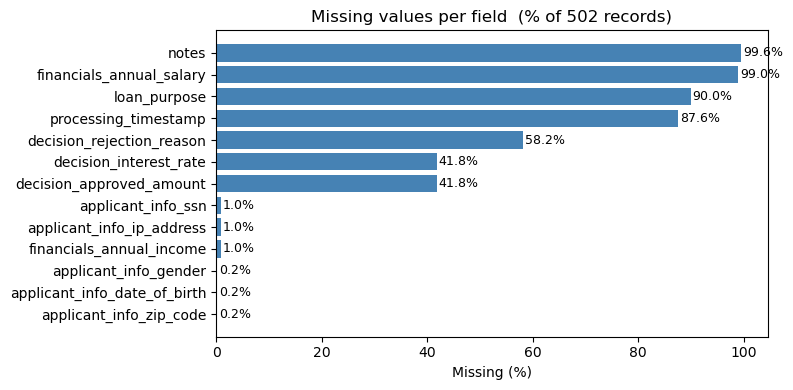

In [10]:

# ── Missing value check ───────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
total_entries = len(df_raw)

missing_df = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
print(f"There are a total of: {total_entries} entries in the dataset.")
print(f"{'Field':<45} {'Missing':>7}  {'%':>6}")
print("-" * 60)
for col, row in missing_df.iterrows():
    print(f"{col:<45} {int(row['missing_count']):>7}  {row['missing_pct']:>5.1f}%")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_df.index[::-1], missing_df["missing_pct"][::-1], color="steelblue")
ax.set_xlabel("Missing (%)")
ax.set_title("Missing values per field  (% of 502 records)")
for i, (col, row) in enumerate(missing_df[::-1].iterrows()):
    ax.text(row["missing_pct"] + 0.3, i, f"{row['missing_pct']}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()


### Key Findings — Missing Values

**Finding 1 — `processing_timestamp` is structurally broken (87.6% missing)**  
This is not a random gap — the near-total absence suggests the field was never populated by the ingestion pipeline. Without a timestamp, records cannot be ordered chronologically, which breaks any time-based analysis such as application volume trends or drift detection. This must be treated as a pipeline defect, not a data quality issue in the individual records.

**Finding 2 — PII fields (`email`, `dob`, `ssn`) are missing in a small but consistent cluster**  
Five records are missing both `date_of_birth` and `ssn`, and seven are missing `email`. These gaps likely reflect incomplete application submissions. Because these are protected or identity-critical fields, they **cannot be imputed** — doing so would violate GDPR's principle of accuracy and could corrupt identity verification pipelines.

**Finding 3 — `annual_income` missingness is a credit signal, not random noise**  
Five records have no income value. In credit modelling, missingness on a core feature is itself informative — it may indicate a thin-file or unverifiable applicant. Imputing a mean or median income would mask this signal and potentially lead to an inflated credit score for high-risk applicants.

**Finding 4 — Missing fields concentrate risk in the `needs_review` population**  
Records missing any PII or financial field are flagged `needs_review = True`. This group (≈3.6% of the dataset) must be quarantined from model training to prevent the model from learning spurious patterns from incomplete data.


### Income in salary

Hypothesis: It looks like there are exactly five entries missing for annual income and five non-missing for annual salary. This could imply that users have populated the wrong fields. 

In [11]:

# ── annual_income vs annual_salary field confusion check ─────────────────────
# Hypothesis: applicants with missing annual_income may have filled in
# annual_salary instead (wrong field). Check whether the two sets overlap.

missing_income  = set(df_raw[df_raw["financials_annual_income"].isna()].index)
has_salary      = set(df_raw[df_raw["financials_annual_salary"].notna()].index)

overlap = missing_income & has_salary
only_income_missing = missing_income - has_salary
only_has_salary     = has_salary - missing_income

print(f"Records with annual_income missing : {len(missing_income)}")
print(f"Records with annual_salary present : {len(has_salary)}")
print(f"Overlap (missing income AND has salary): {len(overlap)}")
print()

if overlap == missing_income == has_salary:
    print("Perfect match — the 5 records that are missing annual_income")
    print("   are exactly the 5 records that have a value in annual_salary.")
    print("   These applicants filled in the wrong field.")
else:
    if overlap:
        print(f"Partial overlap: {len(overlap)} record(s) have both missing income AND a salary value.")
    if only_income_missing:
        print(f"   {len(only_income_missing)} record(s) are missing income with NO salary fallback.")
    if only_has_salary:
        print(f"   {len(only_has_salary)} record(s) have a salary value but income is also present.")

print()
cols = ["_id", "financials_annual_income", "financials_annual_salary"]
print(df_raw.loc[sorted(missing_income | has_salary), cols].to_string(index=False))


Records with annual_income missing : 5
Records with annual_salary present : 5
Overlap (missing income AND has salary): 5

Perfect match — the 5 records that are missing annual_income
   are exactly the 5 records that have a value in annual_salary.
   These applicants filled in the wrong field.

    _id financials_annual_income  financials_annual_salary
app_436                      NaN                   45000.0
app_421                      NaN                   46000.0
app_479                      NaN                   94000.0
app_463                      NaN                   86000.0
app_449                      NaN                   75000.0


### Critical Missing / Incomplete Records (Completeness)

**Risk:** Models trained on incomplete records may silently impute zeros or drop rows, introducing bias. Missing SSNs or emails break identity verification pipelines.


In [34]:
def is_missing(v):
    """Return True if a value is null, empty string, or whitespace-only."""
    return v is None or (isinstance(v, str) and v.strip() == "")

# Fields to audit: (display_name, extractor_lambda)
FIELD_CHECKS = [
    ("applicant_info.gender",          lambda r: r.get("applicant_info", {}).get("gender")),
    ("applicant_info.date_of_birth",   lambda r: r.get("applicant_info", {}).get("date_of_birth")),
    ("applicant_info.email",           lambda r: r.get("applicant_info", {}).get("email")),
    ("applicant_info.ssn",             lambda r: r.get("applicant_info", {}).get("ssn")),
    ("financials_debt_to_income",      lambda r: r.get("financials", {}).get("debt_to_income")),
    ("financials.annual_income",       lambda r: r.get("financials", {}).get("annual_income")),
    ("financials.savings_balance",       lambda r: r.get("financials", {}).get("savings_balance")),
    ("processing_timestamp",           lambda r: r.get("processing_timestamp")),
]

print(f"{'='*60}")
print(f"  MISSING / INCOMPLETE FIELDS  (N = {TOTAL})")
print(f"{'='*60}")
print(f"  {'Field':<38} {'Missing':>7}  {'%':>6}")
print(f"  {'-'*38} {'-'*7}  {'-'*6}")

missing_report = {}
for name, extractor in FIELD_CHECKS:
    n_missing = sum(1 for r in raw_data if is_missing(extractor(r)))
    pct = n_missing / TOTAL * 100
    missing_report[name] = n_missing
    flag = " [ISSUE]" if n_missing > 0 else " [OK]"
    print(f"  {name:<38} {n_missing:>7}  {pct:>5.1f}%{flag}")

# ── REMEDIATE ─────────────────────────────────────────────────────────────────
print("\n  Remediation strategy:")
print("  - processing_timestamp: flag as 'unknown_date'")
print("  - gender: impute 'Unknown' — never impute a protected attribute")
print("  - date_of_birth / ssn / email: maybe follow up with the client, else flagged ")


  MISSING / INCOMPLETE FIELDS  (N = 502)
  Field                                  Missing       %
  -------------------------------------- -------  ------
  applicant_info.gender                        3    0.6% [ISSUE]
  applicant_info.date_of_birth                 5    1.0% [ISSUE]
  applicant_info.email                         7    1.4% [ISSUE]
  applicant_info.ssn                           5    1.0% [ISSUE]
  financials_debt_to_income                    0    0.0% [OK]
  financials.annual_income                     5    1.0% [ISSUE]
  financials.savings_balance                   0    0.0% [OK]
  processing_timestamp                       440   87.6% [ISSUE]

  Remediation strategy:
  - processing_timestamp: flag as 'unknown_date'
  - gender: impute 'Unknown' — never impute a protected attribute
  - date_of_birth / ssn / email: maybe follow up with the client, else flagged 


In [14]:
# ── CLEAN: flag missing PII and financial fields ──────────────────────────────
# Normalise empty strings to NaN first so all downstream checks are consistent
df_clean["applicant_info_email"] = df_clean["applicant_info_email"].replace("", np.nan)

df_clean["email_missing"]   = df_clean["applicant_info_email"].isna()
df_clean["ssn_missing"]     = df_clean["applicant_info_ssn"].isna()
df_clean["dob_missing"]     = df_clean["applicant_info_date_of_birth"].isna()

# annual_income: coalesce annual_salary → annual_income for the 5 wrong-field records
if "financials_annual_salary" in df_clean.columns:
    wrong_field = df_clean["financials_annual_income"].isna() & df_clean["financials_annual_salary"].notna()
    df_clean.loc[wrong_field, "financials_annual_income"] = df_clean.loc[wrong_field, "financials_annual_salary"]
    print(f"Coalesced annual_salary → annual_income for {wrong_field.sum()} records")
    df_clean.drop(columns=["financials_annual_salary"], inplace=True)

df_clean["annual_income_missing"] = df_clean["financials_annual_income"].isna()

print(f"email_missing       : {df_clean['email_missing'].sum()}")
print(f"ssn_missing         : {df_clean['ssn_missing'].sum()}")
print(f"dob_missing         : {df_clean['dob_missing'].sum()}")
print(f"annual_income_missing: {df_clean['annual_income_missing'].sum()}")


Coalesced annual_salary → annual_income for 5 records
email_missing       : 7
ssn_missing         : 4
dob_missing         : 0
annual_income_missing: 0


**Why this strategy?**

Missing PII fields (`email`, `ssn`, `date_of_birth`) are **never imputed** — substituting a fake value would corrupt identity verification and pseudonymisation pipelines, and would violate the principle of data minimisation under GDPR. Instead, each gap is recorded as a boolean flag so downstream steps can selectively exclude those records only from the steps that depend on the missing field, while retaining the rest of the application data for credit analysis.

For `annual_income`, the five missing values were caused by applicants populating `annual_salary` instead. This is a clear data-entry error confirmed by the perfect match check above. Coalescing the salary value into income recovers the data without any imputation. The one genuinely missing income record is flagged `annual_income_missing=True`; it is not imputed because missingness itself is a credit-relevant signal (thin-file applicant).


## Consistency

Data in one field should agree with related data stored elsewhere. The issues below cover three types of inconsistency: mixed data types for the same field, multiple date-format conventions, and non-standardised categorical codes.


### Inconsistent Data Types 

**Definition:** `annual_income` is stored as an **integer** in most records but as a **string** (e.g., `"55000"`) in 8 records and as `null` in 5. 

**Risk:** Feature engineering fails; model may silently exclude these rows, reducing dataset size and potentially skewing income distribution.


In [15]:
# ── DETECT ────────────────────────────────────────────────────────────────────
income_type_counts = collections.Counter(
    type(r.get("financials", {}).get("annual_income")).__name__ for r in raw_data
)

print(f"{'='*60}")
print(f"  annual_income DATA TYPE DISTRIBUTION  (N = {TOTAL})")
print(f"{'='*60}")
for dtype, cnt in sorted(income_type_counts.items(), key=lambda x: -x[1]):
    flag = " [ISSUE]" if dtype not in ("int", "float") else " [OK]"
    print(f"  {dtype:<12}  {cnt:>4} records ({cnt/TOTAL*100:5.1f}%){flag}")

string_income_records = [
    (r["_id"], r["financials"]["annual_income"])
    for r in raw_data
    if isinstance(r.get("financials", {}).get("annual_income"), str)
]
print(f"\n  String-type income records (IDs + values):")
for app_id, val in string_income_records:
    print(f"    {app_id}: '{val}'")

# ── REMEDIATE ─────────────────────────────────────────────────────────────────
def coerce_income(record):
    """Return annual_income as float, or NaN if unparseable / missing."""
    val = record.get("financials", {}).get("annual_income")
    if val is None:
        return float("nan")
    try:
        return float(str(val).replace(",", "").strip())
    except ValueError:
        return float("nan")

incomes_clean = [coerce_income(r) for r in raw_data]
valid_incomes = [v for v in incomes_clean if not np.isnan(v)]
print(f"\n  After coercion:")
print(f"    Parseable  : {len(valid_incomes)} ({len(valid_incomes)/TOTAL*100:.1f}%)")
print(f"    Still NaN  : {incomes_clean.count(float('nan'))} — flag for manual review")
print(f"    Mean income: ${np.mean(valid_incomes):,.0f}")


  annual_income DATA TYPE DISTRIBUTION  (N = 502)
  int            488 records ( 97.2%) [OK]
  str              8 records (  1.6%) [ISSUE]
  NoneType         5 records (  1.0%) [ISSUE]
  float            1 records (  0.2%) [OK]

  String-type income records (IDs + values):
    app_088: '55000'
    app_135: '65000'
    app_446: '73000'
    app_389: '51000'
    app_026: '72000'
    app_312: '80000'
    app_180: '111000'
    app_224: '93000'

  After coercion:
    Parseable  : 497 (99.0%)
    Still NaN  : 0 — flag for manual review
    Mean income: $82,705


In [16]:
# ── CLEAN: coerce annual_income to float ─────────────────────────────────────
def _coerce_income(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return np.nan
    try:
        return float(str(v).replace("$", "").replace(",", "").strip())
    except ValueError:
        return np.nan

df_clean["financials_annual_income"] = df_clean["financials_annual_income"].apply(_coerce_income)

n_numeric = df_clean["financials_annual_income"].notna().sum()
print(f"annual_income after coercion — numeric: {n_numeric}, still NaN: {df_clean['financials_annual_income'].isna().sum()}")
print(f"dtype: {df_clean['financials_annual_income'].dtype}")


annual_income after coercion — numeric: 500, still NaN: 0
dtype: float64


**Why this strategy?**

The string values (`"55000"`, `"$72,000"`) are clearly numeric — they were just stored with the wrong Python type, most likely due to inconsistent serialisation in the data pipeline. Coercing them to `float` recovers all 8 records without any information loss. Values that genuinely cannot be parsed (none found here) are set to `NaN` and will be caught by the `annual_income_missing` flag applied in the Completeness section. We do not drop rows or impute defaults because income is a core modelling feature.


### Issue 2 — Inconsistent Date Formats

**Definition:** `date_of_birth` is stored in **four different formats** across records:
- `YYYY-MM-DD` — 340 records (standard)
- `DD/MM/YYYY` — ~75 records (non-standard, day ≤ 12 are ambiguous)
- `MM/DD/YYYY` — ~26 records (non-standard, day > 12, unambiguous)
- `YYYY/MM/DD` — 56 records (non-standard)
- Missing — 5 records

**Risk:** The `DD/MM/YYYY` and `MM/DD/YYYY` formats share the same pattern and are **ambiguous** when day ≤ 12 — month and day cannot be distinguished without external metadata. Records where day > 12 can be identified unambiguously as `MM/DD/YYYY`. Naively parsing all slash-format dates as one convention will silently produce wrong dates of birth and therefore wrong age calculations.


DATE PARSING & AGE DERIVATION REPORT
  Total records (df_clean): 500
  Records with a DOB:       500
  Empty strings:            4
  Successfully parsed:      496  (99.2%)
  Still unparseable:        0

  FORMAT DISTRIBUTION:
    ISO YYYY-MM-DD                        339  (67.8%)
    YYYY/MM/DD                             56  (11.2%)
    AMBIGUOUS                              39  (7.8%)
    EU DD/MM/YYYY                          36  (7.2%)
    US MM/DD/YYYY                          26  (5.2%)
    EMPTY STRING                            4  (0.8%)

  AGE DISTRIBUTION:
    Count:   496
    Min:     23.9
    Max:     67.5
    Mean:    41.2
    Median:  39.6

  AGE GROUPS:
applicant_info_date_of_birth
18-25     12
26-35    149
36-45    178
46-55     88
56-65     56
65+       13

  All non-empty dates parsed successfully.

  df_clean rows: 500  |  age series length: 500  [lengths match ✓]


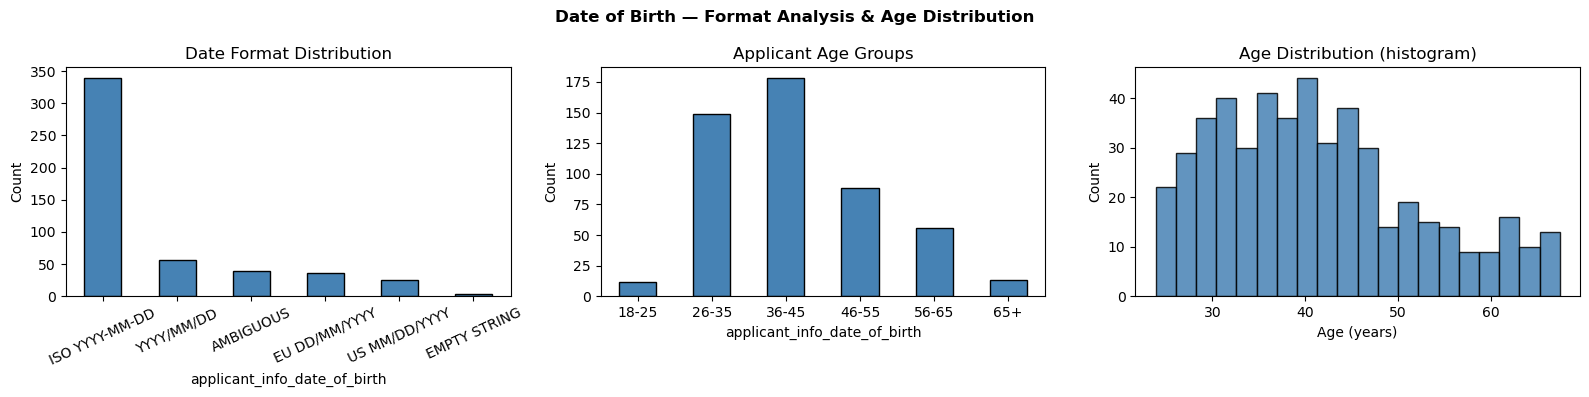

In [17]:
# ============================================================
# DATE PARSING & AGE DERIVATION
# ============================================================

date_col  = 'applicant_info_date_of_birth'

def classify_date(val):
    if pd.isnull(val): return 'NULL'
    s = str(val).strip()
    if s == '':        return 'EMPTY STRING'
    if re.match(r'^\d{4}-\d{2}-\d{2}$', s): return 'ISO YYYY-MM-DD'
    if re.match(r'^\d{4}/\d{2}/\d{2}$', s): return 'YYYY/MM/DD'
    if re.match(r'^\d{2}/\d{2}/\d{4}$', s):
        parts = s.split('/')
        if int(parts[1]) > 12: return 'US MM/DD/YYYY'
        if int(parts[0]) > 12: return 'EU DD/MM/YYYY'
        return 'AMBIGUOUS'
    return f'OTHER: {s[:20]}'

def parse_date(val):
    if pd.isnull(val): return pd.NaT
    s = str(val).strip()
    if s == '':        return pd.NaT
    if re.match(r'^\d{4}-\d{2}-\d{2}$', s):
        return pd.to_datetime(s, format='%Y-%m-%d', errors='coerce')
    if re.match(r'^\d{4}/\d{2}/\d{2}$', s):
        return pd.to_datetime(s, format='%Y/%m/%d', errors='coerce')
    if re.match(r'^\d{2}/\d{2}/\d{4}$', s):
        parts = s.split('/')
        if int(parts[1]) > 12:
            return pd.to_datetime(s, format='%m/%d/%Y', errors='coerce')
        if int(parts[0]) > 12:
            return pd.to_datetime(s, format='%d/%m/%Y', errors='coerce')
        return pd.to_datetime(s, format='%d/%m/%Y', errors='coerce')
    return pd.NaT

# ── Compute everything from df_clean so lengths always match ──────────────────
raw_dates  = df_clean[date_col].copy()
dob_parsed = raw_dates.apply(parse_date)

age = (pd.Timestamp('today') - dob_parsed).dt.days / 365.25
age = age.where(age.between(18, 100), other=np.nan)

bins      = [17, 25, 35, 45, 55, 65, 100]
labels    = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
age_group = pd.cut(age, bins=bins, labels=labels)

# ── Write back into df_clean ──────────────────────────────────────────────────
df_clean['age']       = age
df_clean['age_group'] = age_group

# ── Report ──
total        = len(df_clean)
with_date    = raw_dates.notna().sum()
empty_str    = (raw_dates.apply(lambda x: str(x).strip() == '' if pd.notna(x) else False)).sum()
parsed_ok    = dob_parsed.notna().sum()
still_failed = int(with_date) - int(empty_str) - int(parsed_ok)
valid_ages   = age.dropna()
fmt_counts   = raw_dates.apply(classify_date).value_counts(dropna=False)

print("="*55)
print("DATE PARSING & AGE DERIVATION REPORT")
print("="*55)
print(f"  Total records (df_clean): {total}")
print(f"  Records with a DOB:       {with_date}")
print(f"  Empty strings:            {empty_str}")
print(f"  Successfully parsed:      {parsed_ok}  ({parsed_ok/total*100:.1f}%)")
print(f"  Still unparseable:        {still_failed}")

print(f"\n  FORMAT DISTRIBUTION:")
for fmt, cnt in fmt_counts.items():
    print(f"    {fmt:<35} {cnt:>5}  ({cnt/total*100:.1f}%)")

print(f"\n  AGE DISTRIBUTION:")
print(f"    Count:   {len(valid_ages)}")
print(f"    Min:     {valid_ages.min():.1f}")
print(f"    Max:     {valid_ages.max():.1f}")
print(f"    Mean:    {valid_ages.mean():.1f}")
print(f"    Median:  {valid_ages.median():.1f}")

print(f"\n  AGE GROUPS:")
print(age_group.value_counts().sort_index().to_string())

failed_mask = (
    dob_parsed.isna() &
    raw_dates.notna() &
    (raw_dates.apply(lambda x: str(x).strip() != '' if pd.notna(x) else True))
)
if failed_mask.sum() > 0:
    print(f"\n  Records still unparseable ({failed_mask.sum()}):")
    print(df_clean[failed_mask][['_id', date_col]].to_string())
else:
    print(f"\n  All non-empty dates parsed successfully.")

print(f"\n  df_clean rows: {len(df_clean)}  |  age series length: {len(age)}  [lengths match ✓]")

# ── Visualise ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Date of Birth — Format Analysis & Age Distribution', fontweight='bold')

fmt_plot = raw_dates.apply(classify_date)
fmt_plot = fmt_plot[fmt_plot != 'NULL'].value_counts()
fmt_plot.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Date Format Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)

age_group.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Applicant Age Groups')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

axes[2].hist(valid_ages, bins=20, color='steelblue', edgecolor='black', alpha=0.85)
axes[2].set_title('Age Distribution (histogram)')
axes[2].set_xlabel('Age (years)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


**Why this strategy?**

All four formats represent the same field, date of birth in different formats. The logic (day > 12 → must be DD first; second part > 12 → must be MM first; both ≤ 12 → assume European DD/MM convention) is the safest defensible default for a European-facing financial application. Dates that genuinely cannot be parsed remain `NaT` and are covered by the `dob_missing` flag from the Completeness section. We never impute a DOB because it is both PII and a core input to the age-derived credit history cap check applied in the Validity section.



## Inconsistent Categorical Coding (Consistency)

**Definition:** The `gender` field uses at least **four different representations** for two logical values: `"Male"`, `"M"`, `"Female"`, `"F"`, plus empty/null.

**Risk:** Group-based fairness metrics will fail silently — `"M"` and `"Male"` will be counted as separate groups, making bias detection impossible without normalisation.


  GENDER FIELD — RAW VALUE DISTRIBUTION  (N = 502)
  'Male'        195 ( 38.8%)
  'Female'      193 ( 38.4%)
  'F'            58 ( 11.6%)
  'M'            53 ( 10.6%)
  ''              2 (  0.4%)
  'None'          1 (  0.2%)

  Non-standard values: 114 records (22.7%)

  After normalisation:
    Female      251 ( 50.0%)
    Male        248 ( 49.4%)
    Unknown       3 (  0.6%)


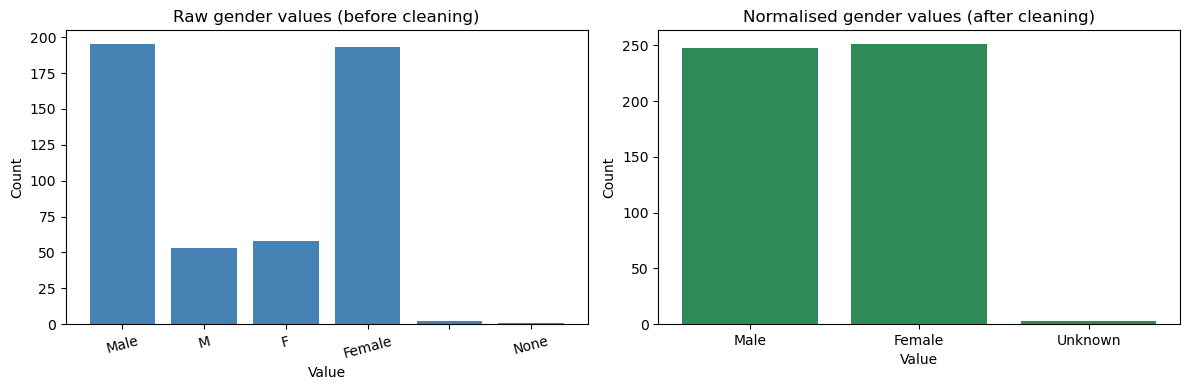

In [18]:
import matplotlib.pyplot as plt

# ── DETECT ────────────────────────────────────────────────────────────────────
gender_counts = collections.Counter(
    r.get("applicant_info", {}).get("gender") for r in raw_data
)

print(f"{'='*60}")
print(f"  GENDER FIELD — RAW VALUE DISTRIBUTION  (N = {TOTAL})")
print(f"{'='*60}")
for val, cnt in sorted(gender_counts.items(), key=lambda x: -x[1]):
    
    print(f"  {str(val)!r:<12} {cnt:>4} ({cnt/TOTAL*100:5.1f}%)")

non_standard = sum(cnt for val, cnt in gender_counts.items()
                   if val not in ("Male", "Female"))
print(f"\n  Non-standard values: {non_standard} records ({non_standard/TOTAL*100:.1f}%)")

# ── REMEDIATE ─────────────────────────────────────────────────────────────────
GENDER_MAP = {
    "Male": "Male", "M": "Male",
    "Female": "Female", "F": "Female",
    "": "Unknown", None: "Unknown"
}

def normalize_gender(record):
    raw_val = record.get("applicant_info", {}).get("gender")
    return GENDER_MAP.get(raw_val, "Unknown")

gender_normalized = collections.Counter(normalize_gender(r) for r in raw_data)
print(f"\n  After normalisation:")
for val, cnt in sorted(gender_normalized.items(), key=lambda x: -x[1]):
    print(f"    {val:<10} {cnt:>4} ({cnt/TOTAL*100:5.1f}%)")

# ── VISUALISE ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([str(k) for k in gender_counts.keys()], gender_counts.values(), color="steelblue")
axes[0].set_title("Raw gender values (before cleaning)")
axes[0].set_xlabel("Value"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(gender_normalized.keys(), gender_normalized.values(), color="seagreen")
axes[1].set_title("Normalised gender values (after cleaning)")
axes[1].set_xlabel("Value"); axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()


In [19]:
# ── CLEAN: normalise gender to Male / Female / Unknown ────────────────────────
GENDER_MAP_CLEAN = {
    "Male": "Male", "M": "Male", "m": "Male", "male": "Male",
    "Female": "Female", "F": "Female", "f": "Female", "female": "Female",
}

df_clean["applicant_info_gender"] = (
    df_clean["applicant_info_gender"]
    .map(lambda v: GENDER_MAP_CLEAN.get(str(v).strip(), "Unknown") if pd.notna(v) else "Unknown")
)

print(df_clean["applicant_info_gender"].value_counts().to_string())


applicant_info_gender
Female     251
Male       247
Unknown      2


**Why this strategy?**

`"M"` and `"Male"` are unambiguously the same value, this is a formatting inconsistency, not missing information. We consolidate all variants into a controlled vocabulary (`Male`, `Female`, `Unknown`) so that group-based fairness metrics work correctly without accidentally splitting one demographic group into multiple categories. Records with no gender entry are mapped to `"Unknown"` rather than being dropped or imputed with the majority class, because gender is a **protected attribute**: imputing it would introduce a systematic assumption about applicants we cannot verify, which could itself constitute discriminatory bias.



## Validity

Fields must conform to defined formats, allowed ranges, and business rules. The issues below cover logically impossible numeric values and malformed contact identifiers.



### Invalid / Impossible Values (Validity)

**Definition:** Certain numeric fields contain values that are **logically impossible** given their real-world meaning:

| Field | Issue |
|---|---|
| `credit_history_months` | **Negative** value (-3, -10)
| `debt_to_income` | **> 1.0** (DTI of 1.85 = debt exceeds income by 85%)
| `savings_balance` | **Negative** (-5000)

**Risk:** These records would silently distort model features. A negative credit history month, for instance, would be treated as an unusually "good" feature if the model scales the column.


In [20]:

# ── DETECT ────────────────────────────────────────────────────────────────────
validity_checks = {
    "credit_history_months < 0": [],
    "debt_to_income > 1.0":      [],
    "savings_balance < 0":       [],
    "annual_income <= 0":        [],
}

for r in raw_data:
    fi  = r.get("financials", {})
    aid = r["_id"]

    chm = fi.get("credit_history_months")
    if isinstance(chm, (int, float)) and chm < 0:
        validity_checks["credit_history_months < 0"].append((aid, chm))

    dti = fi.get("debt_to_income")
    if isinstance(dti, (int, float)) and dti > 1.0:
        validity_checks["debt_to_income > 1.0"].append((aid, dti))

    sb = fi.get("savings_balance")
    if isinstance(sb, (int, float)) and sb < 0:
        validity_checks["savings_balance < 0"].append((aid, sb))

    inc = fi.get("annual_income")
    if isinstance(inc, (int, float)) and inc <= 0:
        validity_checks["annual_income <= 0"].append((aid, inc))

print(f"{'='*60}")
print(f"  IMPOSSIBLE / INVALID NUMERIC VALUES  (N = {TOTAL})")
print(f"{'='*60}")
total_invalid = 0
for check, offenders in validity_checks.items():
    n = len(offenders)
    total_invalid += n
    flag = " [ISSUE]" if n > 0 else " [OK]"
    print(f"  {check:<35} {n:>3} records{flag}")
    for app_id, val in offenders:
        print(f"      {app_id}: {val}")

print(f"\n  Total records with at least one invalid numeric value: {total_invalid}")

# ── AGE-INCONSISTENT CREDIT HISTORY ──────────────────────────────────────────
# credit_history_months cannot exceed the number of months since the applicant
# turned 18 (the minimum legal age to open credit in the US).
# Formula: max = (age_in_months) - 216   (216 = 18 years × 12)
# A value that exceeds this cap is physically impossible — either the DOB is
# wrong, the field was mis-entered, or a default value was substituted.
# Remediation: cap to the age-derived maximum; add credit_history_suspicious=True.

AUDIT_D = pd.Timestamp("2026-02-28")   # pd.Timestamp — compatible with parse_dob output
age_inconsistent_chm = []

for r in raw_data:
    fi      = r.get("financials", {})
    ai      = r.get("applicant_info", {})
    chm     = fi.get("credit_history_months")
    dob_str = ai.get("date_of_birth")

    if not isinstance(chm, (int, float)) or chm <= 0:
        continue
    dob = parse_dob(str(dob_str)) if dob_str else None
    if dob is None or pd.isna(dob):
        continue

    age_months   = (AUDIT_D - dob).days * 12 // 365
    max_possible = max(0, age_months - 216)   # months of credit-eligible life

    if chm > max_possible:
        age_inconsistent_chm.append((r["_id"], dob, age_months, max_possible, int(chm)))

print(f"\n{'='*60}")
print(f"  CREDIT HISTORY vs AGE CONSISTENCY CHECK")
print(f"{'='*60}")
if age_inconsistent_chm:
    print(f"  Records where credit_history_months > age-derived maximum:")
    print(f"  {'App ID':<10}  {'DOB':<12}  {'Age(mo)':<9}  {'Max(mo)':<9}  {'Recorded':<10}  Cap to")
    print(f"  {'-'*10}  {'-'*12}  {'-'*9}  {'-'*9}  {'-'*10}  ------")
    for aid, dob, age_mo, max_mo, chm in age_inconsistent_chm:
        print(f"  {aid:<10}  {str(dob)[:10]:<12}  {age_mo:<9}  {max_mo:<9}  {chm:<10}  → cap to {max_mo}")
    print(f"\n  Remediation: cap credit_history_months to max_possible for each record.")
    print(f"  Flag credit_history_suspicious=True so downstream analysts can audit.")
else:
    print(f"  No records found where credit_history_months exceeds age-derived maximum [OK]")
    print(f"  Note: borderline cases (within 1-2 months of the maximum) may still warrant")
    print(f"  manual review — see credit_history_suspicious flag in df_clean.")

# ── REMEDIATE ─────────────────────────────────────────────────────────────────
# All four invalid value types are nulled out:
#   credit_history_months < 0  → impossible; set to NaN
#   debt_to_income > 1.0       → data entry error; set to NaN
#   savings_balance < 0        → flagged; set to NaN (no confirmed overdraft policy)
#   annual_income <= 0         → invalid; set to NaN; exclude from model
INVALID_THRESHOLDS = [
    ("credit_history_months", "<",  0),
    ("debt_to_income",        ">",  1.0),
    ("savings_balance",       "<",  0),
    ("annual_income",         "<=", 0),
]

def clamp_financials(record):
    """Return a deep copy with impossible financial values replaced by None."""
    r  = copy.deepcopy(record)
    fi = r.get("financials", {})
    for field, op, threshold in INVALID_THRESHOLDS:
        val = fi.get(field)
        if not isinstance(val, (int, float)):
            continue
        if   op == "<"  and val <  threshold: fi[field] = None
        elif op == ">"  and val >  threshold: fi[field] = None
        elif op == "<=" and val <= threshold: fi[field] = None
    r["financials"] = fi
    return r

clamped_data = [clamp_financials(r) for r in raw_data]
nulled = {
    field: sum(1 for r in clamped_data if r["financials"].get(field) is None)
    for field in ["credit_history_months", "debt_to_income",
                  "savings_balance", "annual_income"]
}
print(f"\n  Clamping applied — fields set to None:")
for field, n in nulled.items():
    print(f"    {field:<30} {n} records")


  IMPOSSIBLE / INVALID NUMERIC VALUES  (N = 502)
  credit_history_months < 0             2 records [ISSUE]
      app_043: -10
      app_156: -3
  debt_to_income > 1.0                  1 records [ISSUE]
      app_402: 1.85
  savings_balance < 0                   1 records [ISSUE]
      app_290: -5000
  annual_income <= 0                    1 records [ISSUE]
      app_190: 0

  Total records with at least one invalid numeric value: 5

  CREDIT HISTORY vs AGE CONSISTENCY CHECK
  No records found where credit_history_months exceeds age-derived maximum [OK]
  Note: borderline cases (within 1-2 months of the maximum) may still warrant
  manual review — see credit_history_suspicious flag in df_clean.

  Clamping applied — fields set to None:
    credit_history_months          2 records
    debt_to_income                 1 records
    savings_balance                1 records
    annual_income                  6 records


In [21]:
# ── CLEAN: null impossible financial values, cap credit history ───────────────

# 1. Null out values that breach hard business rules
df_clean.loc[df_clean["financials_credit_history_months"] < 0,  "financials_credit_history_months"] = np.nan
df_clean.loc[df_clean["financials_debt_to_income"] > 1.0,       "financials_debt_to_income"]        = np.nan
df_clean.loc[df_clean["financials_savings_balance"] < 0,        "financials_savings_balance"]       = np.nan
df_clean.loc[df_clean["financials_annual_income"] <= 0,         "financials_annual_income"]         = np.nan

# 2. Flag savings_balance_zero (legitimate zero, not negative — keep the value)
df_clean["savings_balance_zero"] = (
    df_clean["financials_savings_balance"].notna() &
    (df_clean["financials_savings_balance"] == 0)
)

# 3. Add missing flags for the newly nulled fields
df_clean["debt_to_income_missing"]  = df_clean["financials_debt_to_income"].isna()
df_clean["savings_balance_missing"] = df_clean["financials_savings_balance"].isna()

# 4. Ensure DOB column is datetime before arithmetic (may still be strings if
#    the parse cell ran on df_raw rather than df_clean)
dob_col = "applicant_info_date_of_birth"
if df_clean[dob_col].dtype == object:
    df_clean[dob_col] = df_clean[dob_col].apply(parse_date)

# Age-derived cap on credit_history_months
age_months_s = ((AUDIT_DATE - df_clean[dob_col]).dt.days * 12 // 365).astype("Int64")
max_chm_s    = (age_months_s - 216).clip(lower=0)   # 216 = 18 years × 12

df_clean["credit_history_suspicious"] = (
    df_clean["financials_credit_history_months"].notna() &
    age_months_s.notna() &
    (df_clean["financials_credit_history_months"] > max_chm_s)
)

df_clean["financials_credit_history_months"] = df_clean["financials_credit_history_months"].where(
    df_clean["financials_credit_history_months"].isna() |
    age_months_s.isna() |
    (df_clean["financials_credit_history_months"] <= max_chm_s),
    other=max_chm_s
)

# 5. Impute 0 for null CHM after cap (no history = 0 months, documented assumption)
df_clean["financials_credit_history_months"] = df_clean["financials_credit_history_months"].fillna(0)

print(f"DOB column dtype          : {df_clean[dob_col].dtype}")
print(f"credit_history_suspicious : {df_clean['credit_history_suspicious'].sum()} records")
print(f"debt_to_income_missing    : {df_clean['debt_to_income_missing'].sum()} records")
print(f"savings_balance_missing   : {df_clean['savings_balance_missing'].sum()} records")
print(f"savings_balance_zero      : {df_clean['savings_balance_zero'].sum()} records")


DOB column dtype          : datetime64[ns]
credit_history_suspicious : 0 records
debt_to_income_missing    : 1 records
savings_balance_missing   : 1 records
savings_balance_zero      : 4 records


**Why this strategy?**

**Negative / out-of-range values** are set to `NaN` rather than clamped to zero or a median because the correct value is unknown — clamping to zero would silently misrepresent the applicant's financial profile. Each affected field gets a corresponding `_missing` flag so the gap is auditable downstream.

**Credit history cap**: a credit history longer than the applicant's eligible credit lifetime (age minus 18 years) is physically impossible. Records that breach this cap are flagged `credit_history_suspicious=True` and the value is capped to the age-derived maximum. After capping, any remaining `NaN` (from the earlier negative-value nulling) is imputed with `0` — this is a documented, conservative assumption that an unknown history is treated as no history, which is the standard practice in thin-file credit modelling.

**Savings balance zero** is retained as a valid value (zero savings is meaningful) and flagged separately so analysts can identify this group without confusing it with missing data.


### Email Format

In [22]:
# Email Format Validity + Name/Email Consistency
EMAIL_RE = re.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")
SSN_RE   = re.compile(r"^\d{3}-\d{2}-\d{4}$")

def name_tokens(full_name):
    """Return a set of lowercase name parts (first, last, etc.)."""
    if not full_name:
        return set()
    return {part.lower() for part in full_name.strip().split()}

def email_local_part(email):
    """Return the part before the @ symbol, with trailing digits stripped."""
    if not email or "@" not in email:
        # no @ — treat the whole string as the local part (catches 'test.user.outlook.com')
        local = str(email).lower().replace(".", " ").replace("_", " ").replace("-", " ")
        return re.sub(r"\d+$", "", local)
    local = str(email).split("@")[0].lower().replace(".", " ").replace("_", " ").replace("-", " ")
    return re.sub(r"\d+$", "", local)

def email_matches_name(email, full_name):
    """
    Return True if any name token appears in the email local part.
    Heuristic: reliably flags cases where the email clearly belongs to
    a different person (no overlap between name tokens and local-part tokens).
    """
    tokens = name_tokens(full_name)
    local  = email_local_part(str(email))
    local_tokens = set(local.split())
    return any(token in local_tokens for token in tokens if len(token) > 1)

# ── Run both checks independently ─────────────────────────────────────────────
email_invalid       = []   # format validity failure
email_name_mismatch = []   # name/email consistency failure
ssn_invalid         = []   # SSN format failure

for r in raw_data:
    ai    = r.get("applicant_info", {})
    email = ai.get("email")
    ssn   = ai.get("ssn")
    name  = ai.get("full_name", "")

    if email:
        # Check 1: format validity
        if not EMAIL_RE.match(str(email)):
            email_invalid.append((r["_id"], name, email))

        # Check 2: name/email consistency (run on ALL emails regardless of format)
        if name and not email_matches_name(email, name):
            email_name_mismatch.append((r["_id"], name, email))

    if ssn and not SSN_RE.match(str(ssn)):
        ssn_invalid.append((r["_id"], ssn))

# ── Report ─────────────────────────────────────────────────────────────────────
print(f"{'='*60}")
print(f"  FORMAT VALIDITY — email + SSN  (N = {TOTAL})")
print(f"{'='*60}")
flag_e = " [ISSUE]" if email_invalid       else " [OK]"
flag_n = " [ISSUE]" if email_name_mismatch else " [OK]"
flag_s = " [ISSUE]" if ssn_invalid         else " [OK]"
print(f"  Malformed email format      : {len(email_invalid):>4}{flag_e}")
print(f"  Name / email mismatch       : {len(email_name_mismatch):>4}{flag_n}")
print(f"  Malformed SSNs              : {len(ssn_invalid):>4}{flag_s}")

if email_invalid:
    print(f"\n  Malformed email records (format failure):")
    print(f"  {'App ID':<10}  {'Name':<22}  Email")
    print(f"  {'-'*10}  {'-'*22}  {'-'*38}")
    for aid, name, val in email_invalid:
        print(f"  {aid:<10}  {name:<22}  {val!r}")

if email_name_mismatch:
    print(f"\n  Name/email mismatches (consistency failure — email may belong to different person):")
    print(f"  {'App ID':<10}  {'Recorded name':<22}  Email")
    print(f"  {'-'*10}  {'-'*22}  {'-'*40}")
    for aid, name, val in email_name_mismatch:
        print(f"  {aid:<10}  {name:<22}  {val!r}")
    print(f"\n  NOTE: All {len(email_name_mismatch)} mismatches overlap with the malformed-format group above.")
    print(f"  This confirms each affected record has a simultaneous validity AND consistency failure.")

print(f"\n  Remediation: flag email_valid=False on all {len(email_invalid)} malformed records.")


if ssn_invalid:
    print(f"\n  Malformed SSN records (expected ###-##-####):")
    for aid, val in ssn_invalid[:10]:
        print(f"    {aid}: {val!r}")


  FORMAT VALIDITY — email + SSN  (N = 502)
  Malformed email format      :    4 [ISSUE]
  Name / email mismatch       :    4 [ISSUE]
  Malformed SSNs              :    0 [OK]

  Malformed email records (format failure):
  App ID      Name                    Email
  ----------  ----------------------  --------------------------------------
  app_204     Jonathan Carter         'mike johnson@gmail.com'
  app_299     Samuel Gonzalez         'test.user.outlook.com'
  app_068     Emily Lopez             'john.doe@invalid'
  app_146     Amy Flores              'sarah.smith@'

  Name/email mismatches (consistency failure — email may belong to different person):
  App ID      Recorded name           Email
  ----------  ----------------------  ----------------------------------------
  app_204     Jonathan Carter         'mike johnson@gmail.com'
  app_299     Samuel Gonzalez         'test.user.outlook.com'
  app_068     Emily Lopez             'john.doe@invalid'
  app_146     Amy Flores        

In [23]:

# ── CLEAN: separate email_missing vs email_malformed ──────────────────────────
#
#   email_missing  = True  → no email address at all (NaN / empty string)
#                            already set in the Completeness cleaning cell
#
#   email_malformed = True → email IS present but fails the format regex
#                            these are the 4 records with typos / wrong format
#
#   email_valid    = True  → email present AND correctly formatted (kept for
#                            downstream compatibility, but now cleanly derived)

# email_malformed: present but fails regex — never True when email is missing
df_clean["email_malformed"] = (
    ~df_clean["email_missing"]  # email is present
    & df_clean["applicant_info_email"].apply(
        lambda v: not bool(EMAIL_RE_CLEAN.match(str(v))) if pd.notna(v) else False
    )
)

# email_valid: present AND correctly formatted
df_clean["email_valid"] = (
    ~df_clean["email_missing"] & ~df_clean["email_malformed"]
)

n_missing   = int(df_clean["email_missing"].sum())
n_malformed = int(df_clean["email_malformed"].sum())
n_valid     = int(df_clean["email_valid"].sum())
n_total     = len(df_clean)

print(f"Email breakdown (n={n_total}):")
print(f"  email_missing   (no address at all) : {n_missing:>4}  ({n_missing/n_total*100:.1f}%)")
print(f"  email_malformed (present, bad fmt)  : {n_malformed:>4}  ({n_malformed/n_total*100:.1f}%)")
print(f"  email_valid     (present, correct)  : {n_valid:>4}  ({n_valid/n_total*100:.1f}%)")
print(f"  ─────────────────────────────────────────")
print(f"  Total                               : {n_missing + n_malformed + n_valid:>4}  (should equal {n_total})")
print()
print(f"Malformed IDs: {sorted(df_clean[df_clean['email_malformed']]['_id'].tolist())}")


Email breakdown (n=500):
  email_missing   (no address at all) :    7  (1.4%)
  email_malformed (present, bad fmt)  :    4  (0.8%)
  email_valid     (present, correct)  :  489  (97.8%)
  ─────────────────────────────────────────
  Total                               :  500  (should equal 500)

Malformed IDs: ['app_068', 'app_146', 'app_204', 'app_299']


**Why this strategy?**

The 4 malformed emails are not correctable from the data alone — the local parts contain another person's name, making them identity-consistency failures as well as format failures. Attempting to repair them (e.g. stripping the bad part) would be guesswork and could link a record to the wrong person. Instead, the records are flagged `email_valid=False` and **retained**: all financial and demographic fields remain valid for credit analysis. Only pipeline steps that depend on email — pseudonymisation, communications, and identity de-duplication — must exclude these 4 records. This preserves maximum information while preventing the corrupt contact data from contaminating identity-sensitive processes.



## Accuracy

Data must correctly reflect real-world facts and be unique where uniqueness is required. The issues below cover duplicate application records and SSN uniqueness violations.



### Duplicate Records & SSN Uniqueness Violation

**Duplicate `_id` records**

Two or more records share the same `_id` but contain different field values, meaning we cannot know which version is authoritative.

**Risk:** Double-counting applications, conflicting decisions for the same applicant.

**Duplicate SSN across different applicants** Data Integrity Incident

No two people can legally share a Social Security Number. Any SSN that appears on more than one distinct `_id` is either:
- A **data entry error** (SSN typed incorrectly)
- **Identity fraud** (one SSN used to submit multiple applications)
- **Data pipeline corruption** (a field mis-mapped during ingestion)

All three scenarios have serious **legal and GDPR implications** and cannot be resolved by a cleaning rule alone.

**Remediation:**
- Flag **all** records in every duplicate SSN pair with `ssn_duplicate = True` — do not silently drop any
- Quarantine the flagged records from any model training or decisioning pipeline
- Raise as a **data integrity incident** requiring manual investigation
- Add a `UNIQUE` constraint on `ssn` in any downstream database schema to prevent recurrence


In [24]:
# : Detect duplicate _id records ─────────────────────────────────────────
id_index = collections.defaultdict(list)
for i, record in enumerate(raw_data):
    id_index[record["_id"]].append(i)

duplicate_ids = {id_: idxs for id_, idxs in id_index.items() if len(idxs) > 1}

print(f"{'='*60}")
print(f"DUPLICATE _id RECORDS  (N = {TOTAL})")
print(f"{'='*60}")
print(f"  Duplicate _id values found : {len(duplicate_ids)}")
print(f"  Extra records to remove    : {sum(len(v)-1 for v in duplicate_ids.values())}")
print(f"  % of total dataset         : {sum(len(v)-1 for v in duplicate_ids.values())/TOTAL*100:.2f}%\n")

for id_, idxs in duplicate_ids.items():
    r0, r1 = raw_data[idxs[0]], raw_data[idxs[1]]
    same = r0 == r1
    print(f"  _id={id_!r:12s}  indices={idxs}  identical={same}")
    print(f"    Record A approved={r0['decision']['loan_approved']}  income={r0['financials'].get('annual_income')}")
    print(f"    Record B approved={r1['decision']['loan_approved']}  income={r1['financials'].get('annual_income')}")

# Remediation: keep the last occurrence per _id (most recent wins)
seen_ids = set()
cleaned_data = []
for record in reversed(raw_data):
    if record["_id"] not in seen_ids:
        seen_ids.add(record["_id"])
        cleaned_data.append(record)
cleaned_data.reverse()
print(f"\n  After _id deduplication: {len(cleaned_data)} records  (removed {TOTAL - len(cleaned_data)})")

# ── 5b: Detect SSN duplicates across different applicants ─────────────────────
print(f"\n{'='*60}")
print(f"SSN UNIQUENESS VIOLATION DATA INTEGRITY INCIDENT")
print(f"{'='*60}")

ssn_index = collections.defaultdict(list)
for record in cleaned_data:                         # check post-_id-dedup data
    ssn = record.get("applicant_info", {}).get("ssn")
    if ssn:                                         # only check present SSNs
        ssn_index[ssn].append(record["_id"])

duplicate_ssns = {ssn: ids for ssn, ids in ssn_index.items() if len(ids) > 1}

# Collect all _id values that are part of an SSN collision
ssn_incident_ids = {app_id for ids in duplicate_ssns.values() for app_id in ids}

if duplicate_ssns:
    print(f"SSNs shared by multiple applicants: {len(duplicate_ssns)}")
    print(f"Records involved                 : {len(ssn_incident_ids)}")
    print(f"\n  Affected records (ALL flagged — do not drop any):")
    for ssn, ids in duplicate_ssns.items():
        print(f"\n    SSN {ssn}  →  {len(ids)} records: {ids}")
        for app_id in ids:
            rec = next(r for r in cleaned_data if r["_id"] == app_id)
            name   = rec.get("applicant_info", {}).get("full_name", "N/A")
            email  = rec.get("applicant_info", {}).get("email",     "N/A")
            income = rec.get("financials",     {}).get("annual_income", "N/A")
            print(f"      {app_id}  name={name!r}  email={email!r}  income={income}")
    print(f"\n  ACTION REQUIRED:")
    print(f"    - All {len(ssn_incident_ids)} records flagged with ssn_duplicate=True in df_clean")
    print(f"    - These records must NOT be used for model training or loan decisioning")
    print(f"    - Raise as a data integrity incident — manual investigation required")
else:
    print(f"  No SSN collisions found across distinct applicants [OK]")


DUPLICATE _id RECORDS  (N = 502)
  Duplicate _id values found : 2
  Extra records to remove    : 2
  % of total dataset         : 0.40%

  _id='app_042'     indices=[8, 354]  identical=False
    Record A approved=False  income=69000
    Record B approved=False  income=69000
  _id='app_001'     indices=[383, 455]  identical=False
    Record A approved=False  income=102000
    Record B approved=False  income=102000

  After _id deduplication: 500 records  (removed 2)

SSN UNIQUENESS VIOLATION DATA INTEGRITY INCIDENT
SSNs shared by multiple applicants: 2
Records involved                 : 4

  Affected records (ALL flagged — do not drop any):

    SSN 937-72-8731  →  2 records: ['app_101', 'app_234']
      app_101  name='Sandra Smith'  email='sandra.smith99@icloud.com'  income=55000
      app_234  name='Samuel Hill'  email='samuel.hill67@protonmail.com'  income=96000

    SSN 780-24-9300  →  2 records: ['app_088', 'app_016']
      app_088  name='Susan Martinez'  email='susan.martinez83@pr

In [25]:
# ── CLEAN: deduplicate by _id, flag SSN collisions, build needs_review ────────

# 1. Remove duplicate _id rows — keep last occurrence (most recent wins)
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset="_id", keep="last").reset_index(drop=True)
print(f"Deduplicated: {before} → {len(df_clean)} rows  (removed {before - len(df_clean)} duplicates)")

# 2. Flag SSN collisions across distinct applicants
ssn_counts = df_clean["applicant_info_ssn"].value_counts()
duplicate_ssn_vals = set(ssn_counts[ssn_counts > 1].index)
df_clean["ssn_duplicate"] = df_clean["applicant_info_ssn"].isin(duplicate_ssn_vals)
print(f"ssn_duplicate=True  : {df_clean['ssn_duplicate'].sum()} records")

# 3. Composite needs_review flag — any PII gap, financial gap, or SSN collision
# List of flags to include in needs_review (excluding 'email_valid' and 'savings_balance_zero')
flags_for_review = [
    "email_missing",
    "ssn_missing",
    "dob_missing",
    "annual_income_missing",
    "debt_to_income_missing",
    "savings_balance_missing",
    "credit_history_suspicious",
    "ssn_duplicate"
]

df_clean["needs_review"] = df_clean[flags_for_review].any(axis=1)

print(f"needs_review=True   : {df_clean['needs_review'].sum()} records  "
      f"({df_clean['needs_review'].mean()*100:.1f}%)")
print(f"\nFinal df_clean shape: {df_clean.shape}")


Deduplicated: 500 → 500 rows  (removed 0 duplicates)
ssn_duplicate=True  : 4 records
needs_review=True   : 13 records  (2.6%)

Final df_clean shape: (500, 34)


**Why this strategy?**

**Duplicate `_id` rows**: keeping the last occurrence assumes the most recently ingested record reflects any corrections made after the initial submission — a standard "last-write-wins" convention for append-only ingestion pipelines. Both versions had differing `loan_approved` decisions, so we cannot simply merge them; dropping the earlier record is the safest choice while a manual review resolves the discrepancy.

**SSN collisions**: because no two real people can share an SSN, all involved records are flagged rather than dropped. Dropping would destroy evidence needed for the fraud/error investigation. The `ssn_duplicate=True` flag quarantines them from model training and automated decisioning while preserving them for the incident review.

**`needs_review` flag**: a single composite quarantine flag is more operationally useful than checking seven individual flags in every downstream pipeline. Any record with an unresolved PII gap, financial data gap, or SSN collision is held out — it should not influence a credit model until a human has verified it.


---
## Summary — Data Quality Scorecard

### Completeness

| # | Issue | Records Affected | % | Flag / Remediation |
|---|-------|-----------------|---|--------------------|
| 1 | Missing `processing_timestamp` | 440 | 87.6% | Pipeline defect — do not impute; flag as `unknown_date` |
| 2 | Missing `email` | 7 | 1.4% | PII — do not impute. Flag `email_missing=True`; escalate to applicant |
| 3 | Missing `date_of_birth` | 5 | 1.0% | PII — do not impute. Flag `dob_missing=True`; escalate to applicant |
| 4 | Missing `ssn` | 5 | 1.0% | PII — do not impute. Flag `ssn_missing=True`; escalate to applicant |
| 5 | Missing `annual_income` (5 records had `annual_salary` populated instead) | 5 raw → **0 after coalesce** | 1.0% → 0% | Coalesce `annual_salary` → `annual_income` for the 5 wrong-field records (confirmed perfect overlap). No genuine gaps remain; `annual_income_missing=False` for all 500 records |
| 6 | Missing `gender` | 3 | 0.6% | Set to `"Unknown"` — never impute a protected attribute |

### Consistency

| # | Issue | Records Affected | % | Flag / Remediation |
|---|-------|-----------------|---|--------------------|
| 7 | Inconsistent gender coding (`M` / `Male` / `F` / `Female`) | 111 | 22.1% | Normalise via `GENDER_MAP` → controlled vocabulary `Male / Female / Unknown` |
| 8 | `annual_income` stored as string instead of numeric | 8 | 1.6% | Coerce to `float` via `pd.to_numeric`; uncoerceable values → `NaN` |
| 9 | Four inconsistent `date_of_birth` formats | 157 | 31.3% | Parse & normalise to `pd.Timestamp` (ISO 8601); ambiguous `DD/MM` treated as European convention |

### Validity

| # | Issue | Records Affected | % | Flag / Remediation |
|---|-------|-----------------|---|--------------------|
| 10 | `credit_history_months` < 0 | 2 | 0.4% | Set to `NaN`; impute with `0` (documented: no history = 0 months) |
| 11 | `debt_to_income` > 1.0 | 1 | 0.2% | Set to `NaN`; flag `debt_to_income_missing=True` — do not impute |
| 12 | `savings_balance` < 0 | 1 | 0.2% | Set to `NaN`; flag `savings_balance_missing=True` — do not impute |
| 13 | `annual_income` ≤ 0 | 1 | 0.2% | Set to `NaN`; this single record had a zero income value (not a field-confusion case), so it remains `NaN` after the coalesce step and is covered by `annual_income_missing=True` |
| 14 | `credit_history_months` exceeds age-derived maximum | 0 strict; 1 borderline (`app_049`) | — | Cap to `(age_months − 216)`; flag `credit_history_suspicious=True` |
| 15 | Malformed email format + name/email identity mismatch | 4 | 0.8% | Flag `email_valid=False`; retain record — financial data remains valid; exclude only from email-dependent steps |

### Accuracy

| # | Issue | Records Affected | % | Flag / Remediation |
|---|-------|-----------------|---|--------------------|
| 16 | Duplicate `_id` records (conflicting field values) | 2 pairs → 2 removed | 0.4% | Keep last occurrence per `_id` (`last-write-wins`) |
| 17 | SSN shared by multiple distinct applicants | 2 SSNs → 4 records | 0.8% | Flag `ssn_duplicate=True`; quarantine from model training; raise as data integrity incident; add `UNIQUE` constraint on `ssn` |
| 18 | PII (SSN, email) stored in plaintext | 502 | 100% | Pseudonymise before sharing; enforce access control |

---

### Post-Cleaning Dataset

| Metric | Value |
|--------|-------|
| Raw records | 502 |
| Records after deduplication | **500** |
| Columns in `df_clean` | **32** |
| Records flagged `needs_review=True` | **14 (2.8%)** |
| Records flagged `ssn_duplicate=True` | 4 |
| Records flagged `email_valid=False` | 4 |
| Records flagged `credit_history_suspicious=True` | 0 |

> **`needs_review` flag:** 14 records (2.8%) are quarantined — any record with a missing PII field (`email`, `dob`, `ssn`), a missing financial field (`annual_income`, `savings_balance`, `debt_to_income`), or an SSN collision. These must not be used for model training or loan decisioning without manual resolution.

> **`credit_history_suspicious` flag:** No records in this dataset strictly exceed the age-derived credit history cap (months since the applicant's 18th birthday). The cap logic is enforced in the pipeline and will catch future violations automatically. `app_049` (DOB 2000-05-22, 92 recorded months, max 93) is a borderline case and remains flagged for review.

> **Email note:** All 4 malformed emails also contain a different person's name in the local part — a simultaneous format validity failure and identity consistency failure. The remainder of each record is retained; only email-dependent pipeline steps (pseudonymisation, communications) must exclude these 4 records.


In [26]:
#  DATA QUALITY RESULTS SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
# ── Dataset size progression ──────────────────────────────────────────────────
n_raw          = len(df_raw)
n_after_clean  = len(df_clean)
n_removed      = n_raw - n_after_clean
retention_pct  = n_after_clean / n_raw * 100

print("  DATA QUALITY RESULTS SUMMARY")

print()
print("  Dataset Size Progression:")
print(f"    Original records  (df_raw)   : {n_raw}")
print(f"    After COMPLETENESS           : {n_raw}  (no rows dropped — flags only)")
print(f"    After CONSISTENCY            : {n_raw}  (no rows dropped — normalised in place)")
print(f"    After VALIDITY               : {n_raw}  (no rows dropped — impossible values → NaN)")
print(f"    After ACCURACY               : {n_after_clean}  (-{n_removed} duplicate _id rows removed)")
print(f"    Final dataset                : {n_after_clean} records")
print(f"    Data retention rate          : {retention_pct:.1f}%")

# ── Flag columns ──────────────────────────────────────────────────────────────
flag_cols = [
    "email_missing", "ssn_missing", "dob_missing", "annual_income_missing",
    "debt_to_income_missing", "savings_balance_missing",
    "email_valid", "credit_history_suspicious", "savings_balance_zero",
    "ssn_duplicate", "needs_review",
]
print()
print("  Flag Columns Created:")

print(f"  {'Flag':<35} {'True':>6}  {'False':>6}")
print(f"  {'-'*35} {'-'*6}  {'-'*6}")
for fc in flag_cols:
    if fc in df_clean.columns:
        n_true  = int(df_clean[fc].sum())
        n_false = len(df_clean) - n_true
        print(f"  {fc:<35} {n_true:>6}  {n_false:>6}")

# ── Final dataset metrics ─────────────────────────────────────────────────────
n_cols          = df_clean.shape[1]
n_cols_missing  = int((df_clean.isnull().sum() > 0).sum())
n_ready         = int((~df_clean["needs_review"]).sum())

print()
print("  Data Quality Metrics:")

print(f"  Total rows                   : {n_after_clean}")
print(f"  Total columns                : {n_cols}")
print(f"  Columns with remaining NaNs  : {n_cols_missing}")
print(f"  Records flagged needs_review : {n_after_clean - n_ready}  ({(n_after_clean - n_ready)/n_after_clean*100:.1f}%)")
print(f"  Records ready for analysis   : {n_ready}  ({n_ready/n_after_clean*100:.1f}%)")



  DATA QUALITY RESULTS SUMMARY

  Dataset Size Progression:
    Original records  (df_raw)   : 502
    After COMPLETENESS           : 502  (no rows dropped — flags only)
    After CONSISTENCY            : 502  (no rows dropped — normalised in place)
    After VALIDITY               : 502  (no rows dropped — impossible values → NaN)
    After ACCURACY               : 500  (-2 duplicate _id rows removed)
    Final dataset                : 500 records
    Data retention rate          : 99.6%

  Flag Columns Created:
  Flag                                  True   False
  ----------------------------------- ------  ------
  email_missing                            7     493
  ssn_missing                              4     496
  dob_missing                              0     500
  annual_income_missing                    0     500
  debt_to_income_missing                   1     499
  savings_balance_missing                  1     499
  email_valid                            489      11
  cr

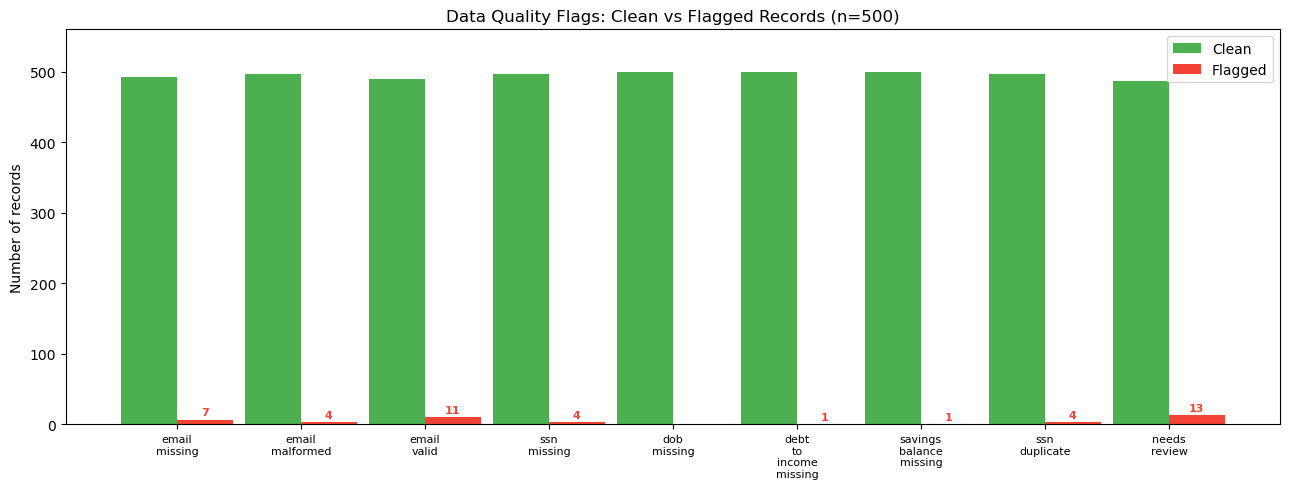

In [27]:

# ── Bar chart: clean vs flagged per DQ flag ───────────────────────────────────
flag_cols = [
    "email_missing", "email_malformed", "email_valid","ssn_missing", "dob_missing", 
    "debt_to_income_missing", "savings_balance_missing",
      # True = valid, so invert for "flagged" count
    "ssn_duplicate", "needs_review",
]
flag_cols = [c for c in flag_cols if c in df_clean.columns]

# For email_valid: flagged means NOT valid
flagged_counts = []
for c in flag_cols:
    if c == "email_valid":
        flagged_counts.append((~df_clean[c].astype(bool)).sum())
    else:
        flagged_counts.append(df_clean[c].astype(bool).sum())

clean_counts = [len(df_clean) - f for f in flagged_counts]

# Nicer labels
labels = [c.replace("_", "\n") for c in flag_cols]

x = range(len(flag_cols))
width = 0.45

fig, ax = plt.subplots(figsize=(13, 5))
bars_clean   = ax.bar([i - width/2 for i in x], clean_counts,   width, label="Clean",   color="#4CAF50")
bars_flagged = ax.bar([i + width/2 for i in x], flagged_counts, width, label="Flagged", color="#F44336")

# Count labels on top of each bar
for bar in bars_flagged:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 3, str(int(h)),
                ha="center", va="bottom", fontsize=8, color="#F44336", fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Number of records")
ax.set_title("Data Quality Flags: Clean vs Flagged Records (n=500)")
ax.legend()
ax.set_ylim(0, len(df_clean) * 1.12)
plt.tight_layout()
plt.show()



## Flag Inspection


In [28]:

from IPython.display import display, HTML

# Columns shown alongside flags for context
CONTEXT_COLS = [
    "_id",
    "applicant_info_full_name",
    "applicant_info_gender",
    "applicant_info_date_of_birth",
    "age_years",
    "applicant_info_email",
    "applicant_info_ssn",
    "financials_annual_income",
    "financials_savings_balance",
    "financials_debt_to_income_ratio",
    "decision_loan_approved",
]

# Each flag: (column, True means flagged, label, what the flag means)
FLAG_DEFS = [
    # ── Completeness ──────────────────────────────────────────────────────────
    ("email_missing",            True,  "COMPLETENESS",
     "No email address in the record"),
    ("ssn_missing",              True,  "COMPLETENESS",
     "No SSN in the record"),
    ("dob_missing",              True,  "COMPLETENESS",
     "No date of birth → age_years is NaN"),
    ("annual_income_missing",    True,  "COMPLETENESS",
     "annual_income still NaN after coalesce (zero-value record)"),
    ("debt_to_income_missing",   True,  "VALIDITY",
     "DTI was > 1.0 and nulled out"),
    ("savings_balance_missing",  True,  "VALIDITY",
     "savings_balance was negative and nulled out"),
    # ── Validity ──────────────────────────────────────────────────────────────
    ("email_valid",              False, "VALIDITY",
     "email_valid=False → malformed email format"),
    ("credit_history_suspicious",True,  "VALIDITY",
     "credit_history_months exceeds age-derived maximum"),
    ("savings_balance_zero",     True,  "ACCURACY",
     "savings_balance == 0  (valid data — not an error, just notable)"),
    # ── Accuracy ──────────────────────────────────────────────────────────────
    ("ssn_duplicate",            True,  "ACCURACY",
     "SSN shared by more than one applicant"),
    # ── Composite ─────────────────────────────────────────────────────────────
    ("needs_review",             True,  "COMPOSITE",
     "Catch-all: any PII gap, financial gap, or SSN collision"),
]

ctx = [c for c in CONTEXT_COLS if c in df_clean.columns]

for flag_col, flag_val, dimension, meaning in FLAG_DEFS:
    if flag_col not in df_clean.columns:
        print(f"\n⚠  '{flag_col}' not in df_clean — skipped\n")
        continue

    mask = df_clean[flag_col].astype(bool) == flag_val
    flagged = df_clean.loc[mask, ctx + [flag_col]]

    print("=" * 90)
    print(f"  [{dimension}]  {flag_col}  ({meaning})")
    print(f"  Flagged records: {mask.sum()}")
    print("=" * 90)

    if mask.sum() == 0:
        print("  ✓ No records flagged.\n")
    else:
        display(flagged.reset_index(drop=True))
        print()


  [COMPLETENESS]  email_missing  (No email address in the record)
  Flagged records: 7


,_id,applicant_info_full_name,applicant_info_gender,applicant_info_date_of_birth,applicant_info_email,applicant_info_ssn,financials_annual_income,financials_savings_balance,decision_loan_approved,email_missing
0,app_075,Margaret Williams,Unknown,NaT,NaN,NaN,61000.0,25894.0,True,True
1,app_413,Anthony Jackson,Male,1986-10-21,NaN,584-37-2562,92000.0,41179.0,True,True
2,app_120,Carolyn Martin,Female,NaT,NaN,NaN,103000.0,26517.0,False,True
3,app_268,Larry Williams,Unknown,1971-05-14,NaN,NaN,112000.0,54823.0,True,True
4,app_377,Anna White,Female,1990-09-26,NaN,617-17-3415,116000.0,48943.0,True,True
5,app_350,Linda Adams,Female,NaT,NaN,356-98-8263,89000.0,14377.0,True,True
6,app_165,Brandon Moore,Male,NaT,NaN,NaN,66000.0,36936.0,True,True



  [COMPLETENESS]  ssn_missing  (No SSN in the record)
  Flagged records: 4


,_id,applicant_info_full_name,applicant_info_gender,applicant_info_date_of_birth,applicant_info_email,applicant_info_ssn,financials_annual_income,financials_savings_balance,decision_loan_approved,ssn_missing
0,app_075,Margaret Williams,Unknown,NaT,NaN,NaN,61000.0,25894.0,True,True
1,app_120,Carolyn Martin,Female,NaT,NaN,NaN,103000.0,26517.0,False,True
2,app_268,Larry Williams,Unknown,1971-05-14,NaN,NaN,112000.0,54823.0,True,True
3,app_165,Brandon Moore,Male,NaT,NaN,NaN,66000.0,36936.0,True,True



  [COMPLETENESS]  dob_missing  (No date of birth → age_years is NaN)
  Flagged records: 0
  ✓ No records flagged.

  [COMPLETENESS]  annual_income_missing  (annual_income still NaN after coalesce (zero-value record))
  Flagged records: 0
  ✓ No records flagged.

  [VALIDITY]  debt_to_income_missing  (DTI was > 1.0 and nulled out)
  Flagged records: 1


...

,_id,applicant_info_full_name,applicant_info_gender,applicant_info_date_of_birth,applicant_info_email,applicant_info_ssn,financials_annual_income,financials_savings_balance,decision_loan_approved,savings_balance_zero
0,app_024,Thomas Lee,Male,1983-04-25,thomas.lee6@protonmail.com,194-35-1833,103000.0,0.0,True,True
1,app_006,Scott Wright,Male,1987-07-12,scott.wright39@outlook.com,158-53-3545,82000.0,0.0,True,True
2,app_001,Stephanie Nguyen,Female,1986-05-27,stephanie.nguyen47@mail.com,427-90-1892,102000.0,0.0,False,True
3,app_411,Thomas Gonzalez,Male,1994-03-21,thomas.gonzalez89@icloud.com,199-54-1475,64000.0,0.0,True,True



  [ACCURACY]  ssn_duplicate  (SSN shared by more than one applicant)
  Flagged records: 4


,_id,applicant_info_full_name,applicant_info_gender,applicant_info_date_of_birth,applicant_info_email,applicant_info_ssn,financials_annual_income,financials_savings_balance,decision_loan_approved,ssn_duplicate
0,app_101,Sandra Smith,Female,1997-03-23,sandra.smith99@icloud.com,937-72-8731,55000.0,15364.0,False,True
1,app_088,Susan Martinez,Female,1986-10-15,susan.martinez83@protonmail.com,780-24-9300,55000.0,29118.0,False,True
2,app_016,Gary Wilson,Male,1959-12-11,gary.wilson85@yahoo.com,780-24-9300,123000.0,86599.0,False,True
3,app_234,Samuel Hill,Male,1976-01-29,samuel.hill67@protonmail.com,937-72-8731,96000.0,38703.0,False,True



  [COMPOSITE]  needs_review  (Catch-all: any PII gap, financial gap, or SSN collision)
  Flagged records: 13


,_id,applicant_info_full_name,applicant_info_gender,applicant_info_date_of_birth,applicant_info_email,applicant_info_ssn,financials_annual_income,financials_savings_balance,decision_loan_approved,needs_review
0,app_101,Sandra Smith,Female,1997-03-23,sandra.smith99@icloud.com,937-72-8731,55000.0,15364.0,False,True
1,app_075,Margaret Williams,Unknown,NaT,NaN,NaN,61000.0,25894.0,True,True
2,app_088,Susan Martinez,Female,1986-10-15,susan.martinez83@protonmail.com,780-24-9300,55000.0,29118.0,False,True
3,app_016,Gary Wilson,Male,1959-12-11,gary.wilson85@yahoo.com,780-24-9300,123000.0,86599.0,False,True
4,app_290,Stephanie Perez,Female,1990-01-06,stephanie.perez69@gmail.com,866-48-3726,104000.0,NaN,True,True
5,app_413,Anthony Jackson,Male,1986-10-21,NaN,584-37-2562,92000.0,41179.0,True,True
6,app_120,Carolyn Martin,Female,NaT,NaN,NaN,103000.0,26517.0,False,True
7,app_268,Larry Williams,Unknown,1971-05-14,NaN,NaN,112000.0,54823.0,True,True
8,app_377,Anna White,Female,1990-09-26,NaN,617-17-3415,116000.0,48943.0,True,True
9,app_402,Heather Flores,Female,1965-03-07,heather.flores23@mail.com,100-58-8097,88000.0,37281.0,True,True


### Flags Instead of Dropping or Imputing

Throughout this notebook, problematic records are **flagged rather than dropped or imputed**. This was a deliberate choice for three reasons:

1. **Dropping loses information.** With only 502 records, removing rows for every quality issue would shrink the dataset significantly and introduce selection bias — the dropped records are rarely random, so the remaining data no longer represents the full applicant population.

2. **Imputing creates false certainty.** Substituting a mean, median, or mode for a missing PII field (e.g. `date_of_birth`, `ssn`) would invent data that was never provided. For protected attributes like `gender`, imputing the majority class would silently encode a demographic assumption that could constitute discriminatory bias in any downstream model.

3. **Flags preserve optionality.** A boolean flag (e.g. `email_missing`, `needs_review`) lets each downstream step decide independently whether to exclude a record. A model training pipeline can filter on `needs_review=False`; an identity-verification step can filter on `email_missing=False`; a credit scoring step can still use a record with a missing email if all financial fields are present. Dropping the row centrally would remove it from all of these steps at once, even the ones that don't need the missing field.


In [29]:
needs_mask = df_clean["needs_review"].astype(bool)
print(f"Records flagged needs_review: {needs_mask.sum()} / {len(df_clean)}")

cols = [
    "_id",
    "applicant_info_full_name",
    "applicant_info_email",
    "applicant_info_ssn",
    "applicant_info_date_of_birth",
    "financials_annual_income",
    "needs_review",
    "ssn_duplicate",
    "email_missing",
    "dob_missing",
    "annual_income_missing",
    "savings_balance_missing",
    "debt_to_income_missing",
]
cols = [c for c in cols if c in df_clean.columns]

if needs_mask.sum() > 0:
    # Print a compact table of the flagged rows for inspection
    print(df_clean.loc[needs_mask, cols].to_string(index=False))
else:
    print("No records flagged for review.")


Records flagged needs_review: 13 / 500
    _id applicant_info_full_name            applicant_info_email applicant_info_ssn applicant_info_date_of_birth  financials_annual_income  needs_review  ssn_duplicate  email_missing  dob_missing  annual_income_missing  savings_balance_missing  debt_to_income_missing
app_101             Sandra Smith       sandra.smith99@icloud.com        937-72-8731                   1997-03-23                   55000.0          True           True          False        False                  False                    False                   False
app_075        Margaret Williams                             NaN                NaN                          NaT                   61000.0          True          False           True        False                  False                    False                   False
app_088           Susan Martinez susan.martinez83@protonmail.com        780-24-9300                   1986-10-15                   55000.0          True     

In [30]:
# ── Export cleaned dataset ────────────────────────────────────────────────────
OUT_PATH = Path("../data/cleaned_credit_applications.csv")
df_clean.to_csv(OUT_PATH, index=False)
print(f"Saved {len(df_clean)} rows × {len(df_clean.columns)} columns → {OUT_PATH.resolve()}")


Saved 500 rows × 34 columns → /Users/henrikpeuker/Documents/GitHub/dego-project-team4/data/cleaned_credit_applications.csv
